In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [4]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score,davies_bouldin_score


df=pd.read_csv('wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.shape

(178, 14)

In [8]:
df.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [9]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
173    False
174    False
175    False
176    False
177    False
Length: 178, dtype: bool

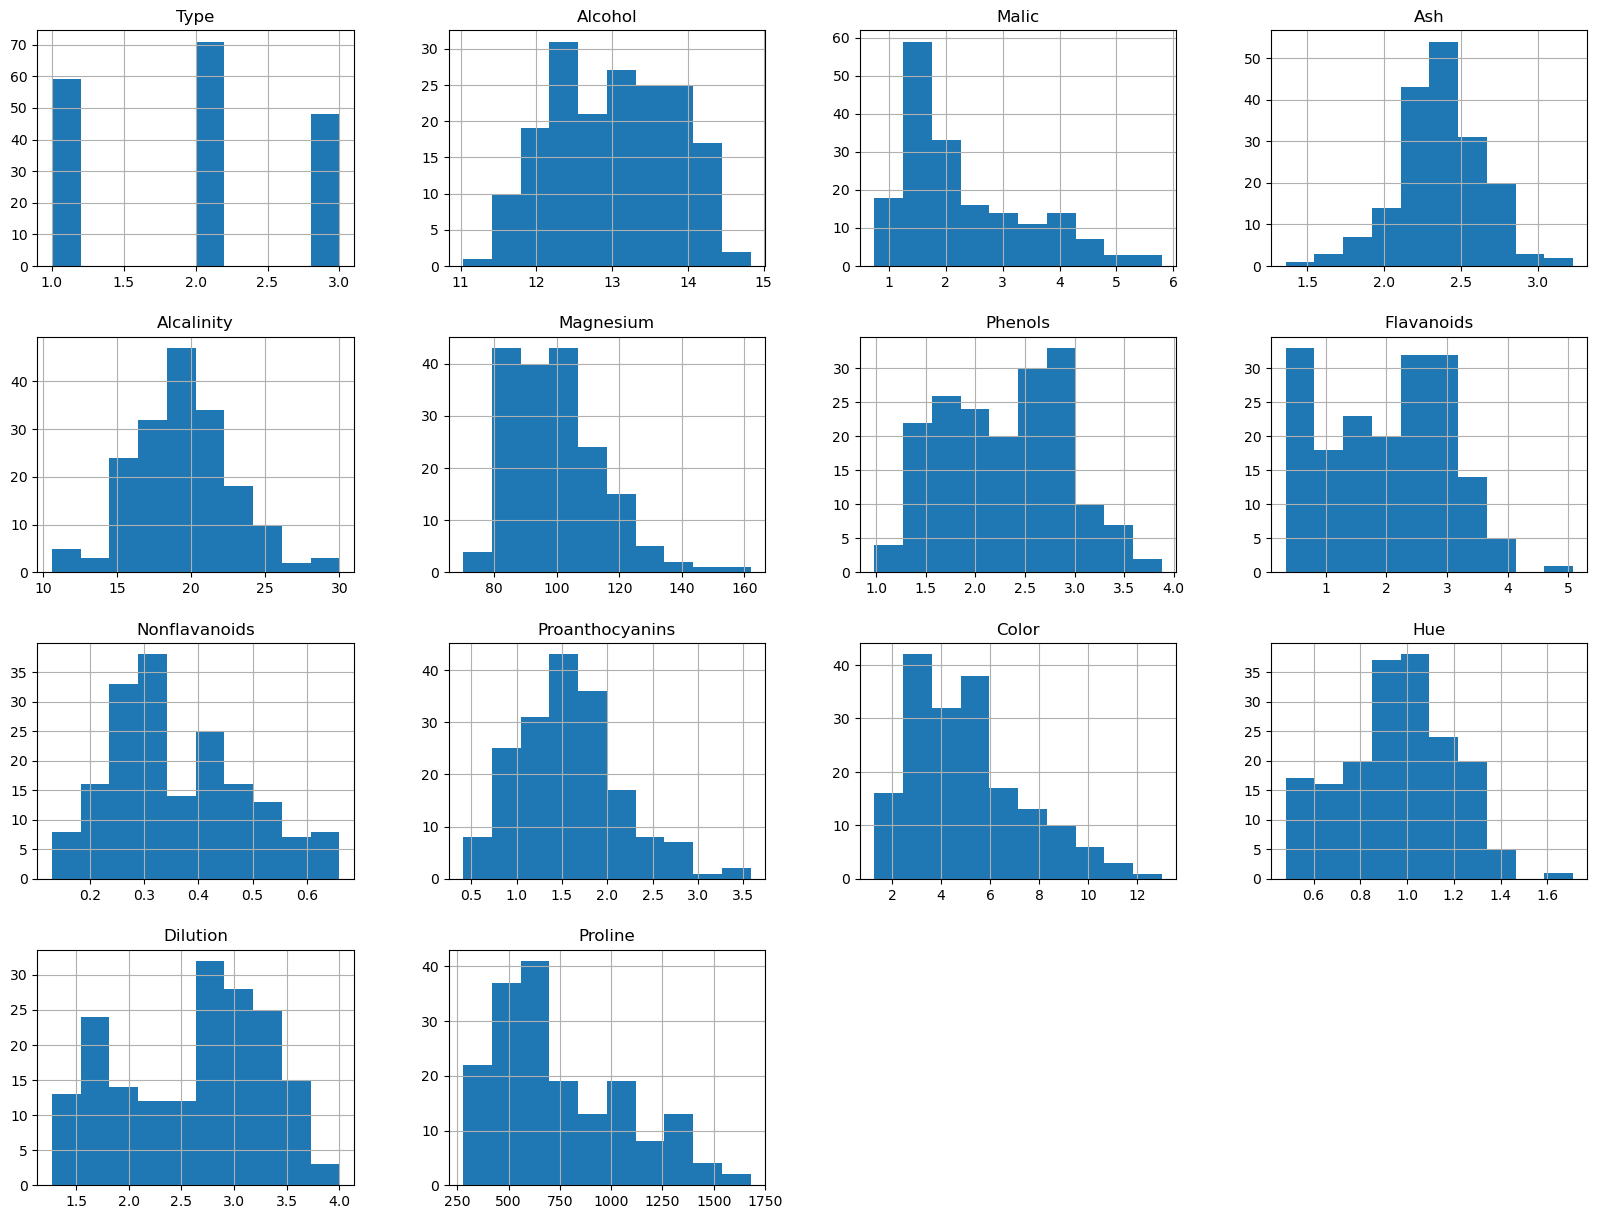

In [10]:
df.hist(figsize=(20,15))
plt.show()

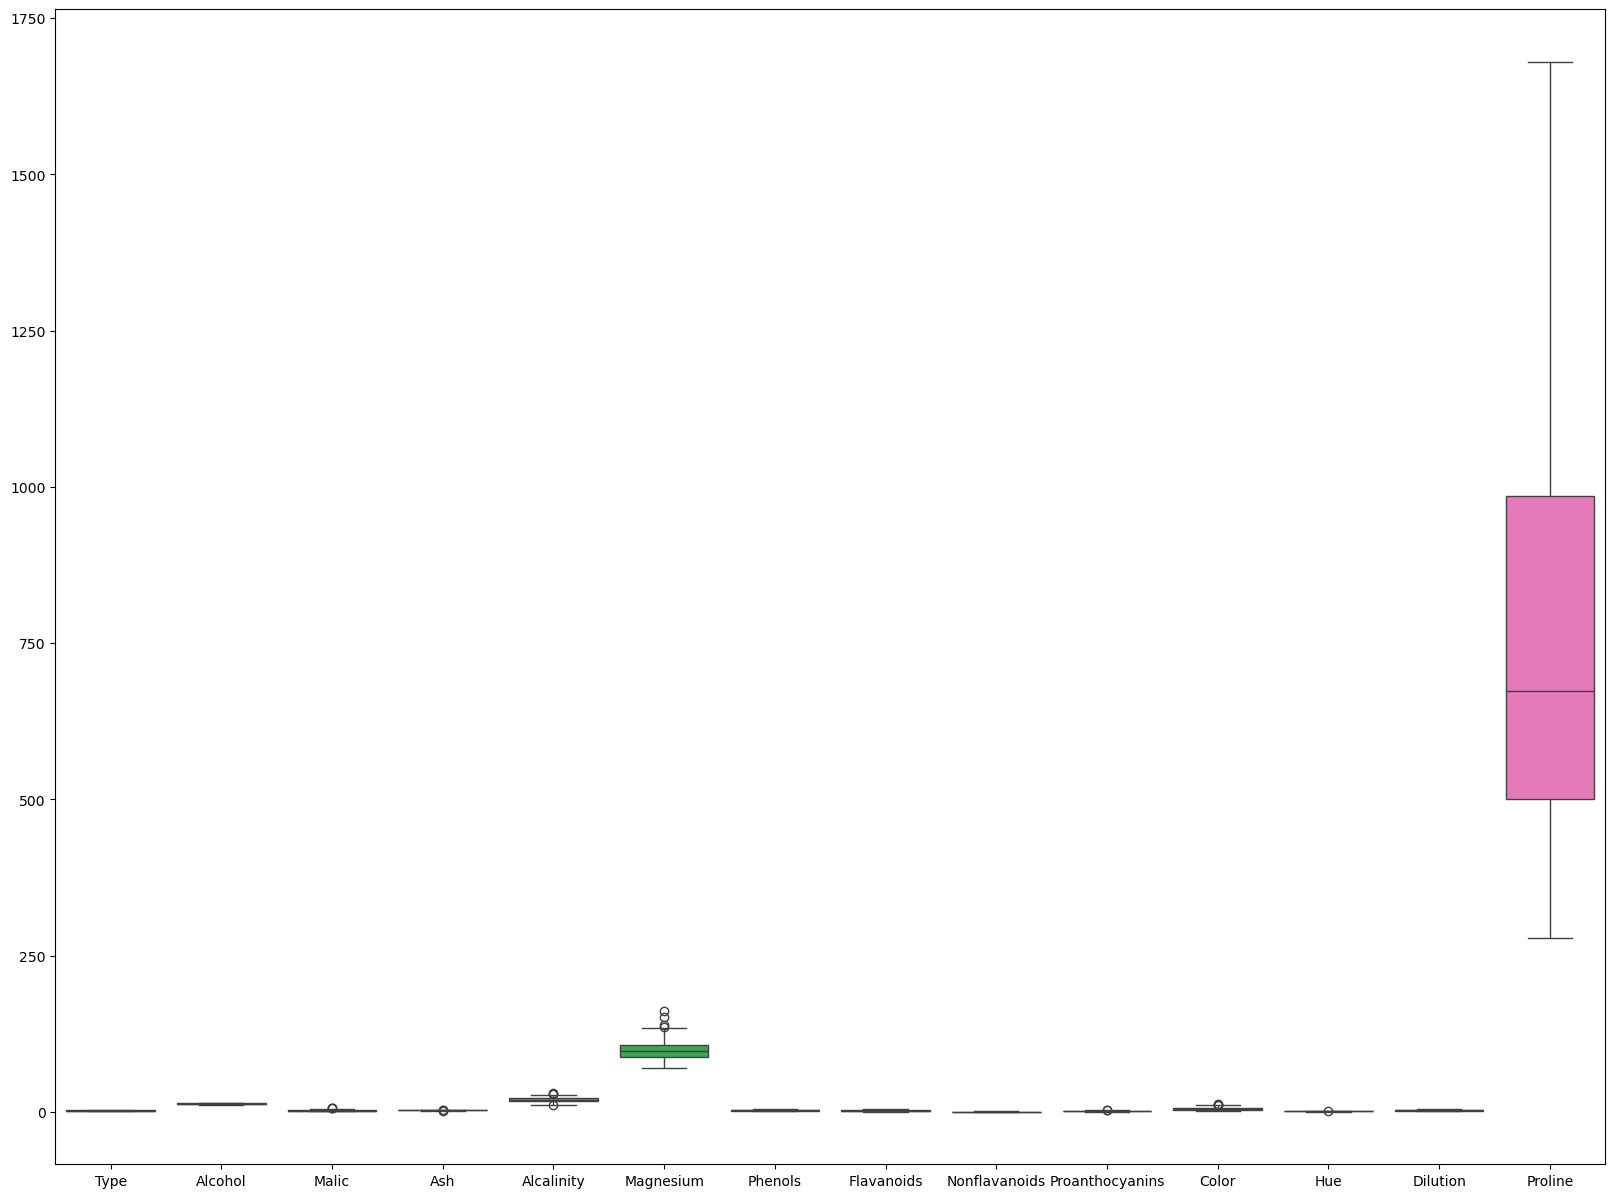

In [11]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.show()

In [12]:
df.skew()

Type               0.107431
Alcohol           -0.051482
Malic              1.039651
Ash               -0.176699
Alcalinity         0.213047
Magnesium          1.098191
Phenols            0.086639
Flavanoids         0.025344
Nonflavanoids      0.450151
Proanthocyanins    0.517137
Color              0.868585
Hue                0.021091
Dilution          -0.307285
Proline            0.767822
dtype: float64

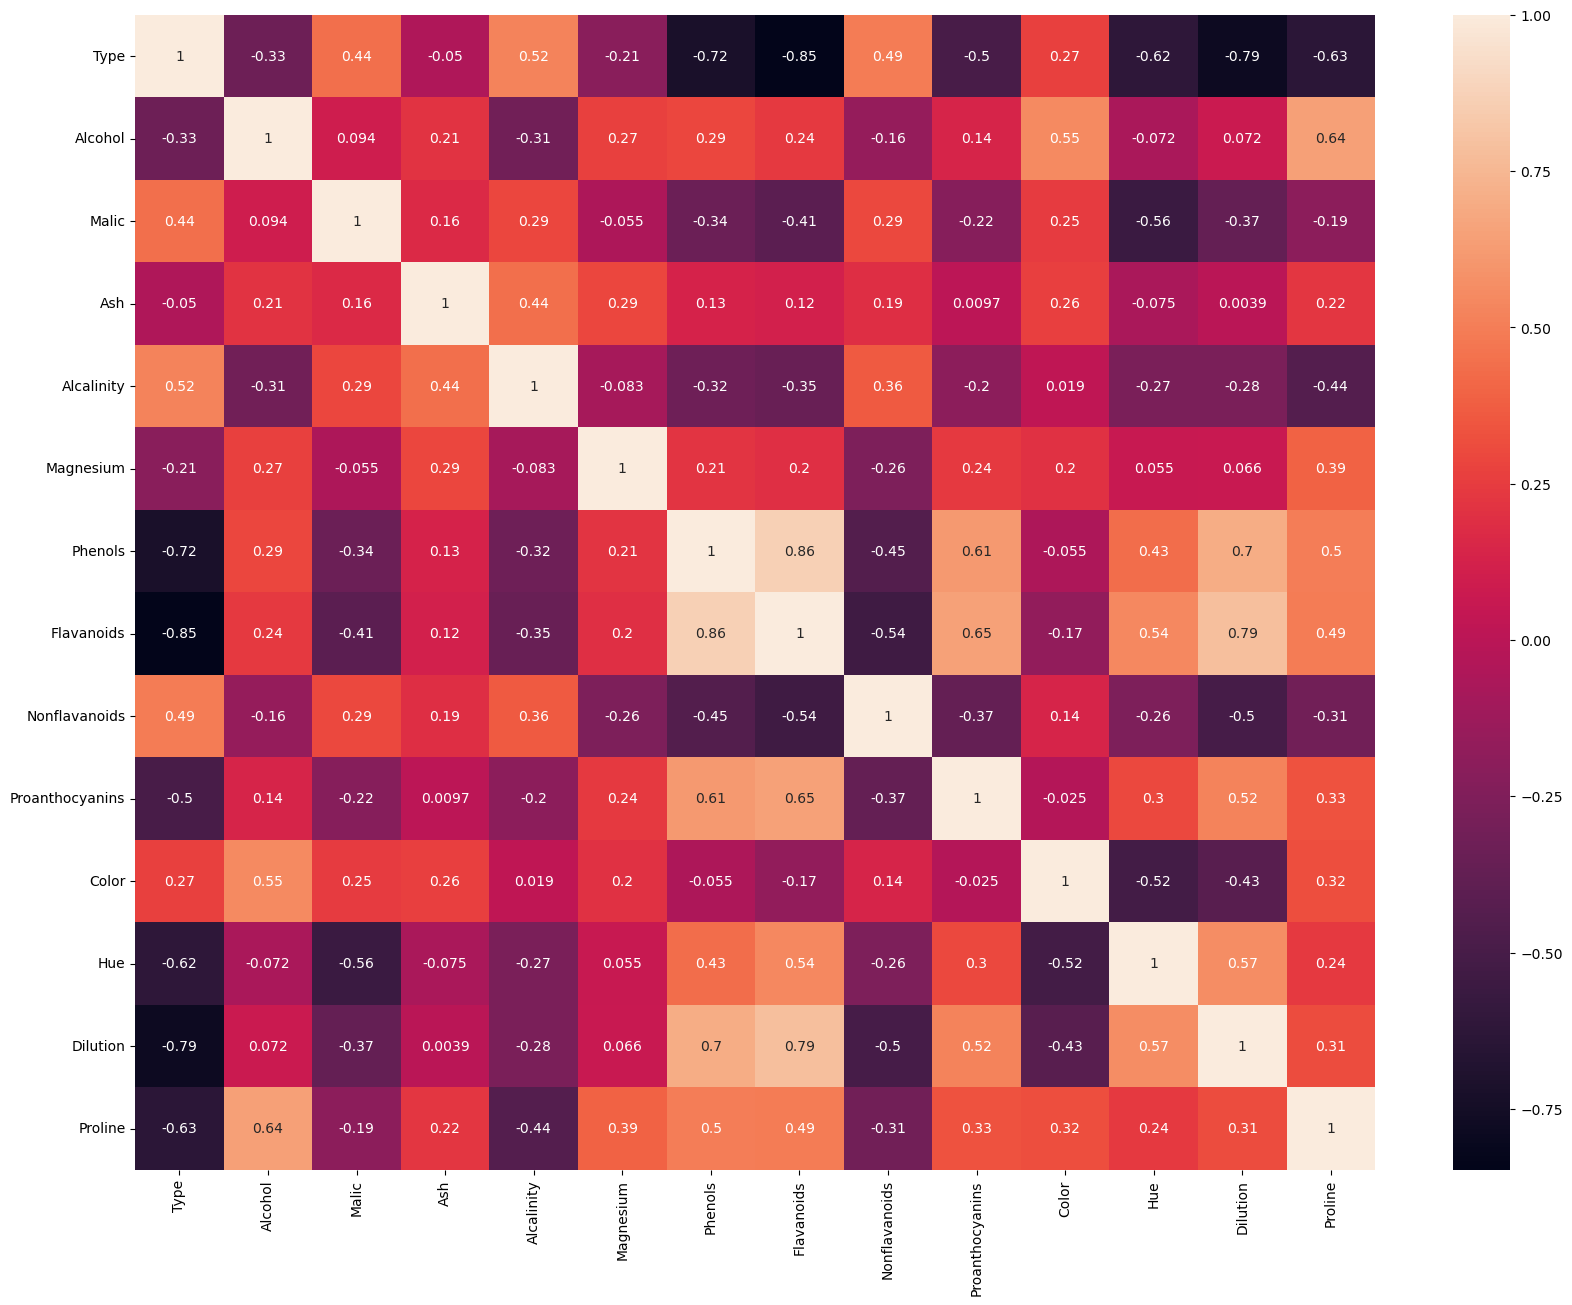

In [13]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [14]:
x=df.drop('Type',axis=1)
y=df['Type']
ss=StandardScaler()
scaled_x=ss.fit_transform(x)
scaled_x

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

In [15]:
pca=PCA(n_components=2)

In [16]:
x_pca=pca.fit_transform(x)
x_pca

array([[ 3.18562979e+02,  2.14921307e+01],
       [ 3.03097420e+02, -5.36471768e+00],
       [ 4.38061133e+02, -6.53730945e+00],
       [ 7.33240139e+02,  1.92729032e-01],
       [-1.15714285e+01,  1.84899946e+01],
       [ 7.03231192e+02, -3.32158674e-01],
       [ 5.42971581e+02, -1.35189666e+01],
       [ 5.48401860e+02,  1.14494324e+01],
       [ 2.98036863e+02, -8.18015784e+00],
       [ 2.98049553e+02, -7.10154294e+00],
       [ 7.63079712e+02, -8.33431723e+00],
       [ 5.32943228e+02, -1.42876338e+01],
       [ 5.72834410e+02, -2.10050143e+01],
       [ 4.02925358e+02, -1.61026352e+01],
       [ 8.00053394e+02, -1.21184472e+01],
       [ 5.63245578e+02,  2.21482866e+00],
       [ 5.33379651e+02,  1.08048022e+01],
       [ 3.83317591e+02,  8.47741982e+00],
       [ 9.33118387e+02, -8.35447844e+00],
       [ 9.84031775e+01,  1.43926594e+01],
       [ 3.35935940e+01,  2.55679565e+01],
       [ 2.31464375e+01,  1.81747309e+00],
       [ 2.88093030e+02, -3.96304175e+00],
       [ 2.

In [17]:
pca.explained_variance_ratio_

array([0.99809123, 0.00173592])

In [22]:
X_train,X_test,y_train,y_test=train_test_split(scaled_x,y,test_size=0.2,random_state=42)

In [23]:
model = KMeans(n_clusters=3,random_state=42)

labels = model.fit_predict(scaled_x)

sil_score = silhouette_score(scaled_x, labels)

db_score = davies_bouldin_score(scaled_x, labels)

print("Silhouette Score:",sil_score)
print("Davies Bouldin Score:",db_score)

Silhouette Score: 0.2848589191898987
Davies Bouldin Score: 1.3891879777181648


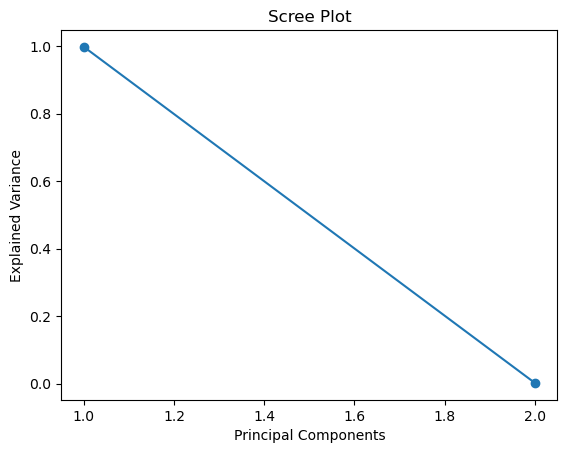

In [26]:
explained_variance = pca.explained_variance_ratio_

plt.plot(range(1,len(explained_variance)+1),explained_variance,marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

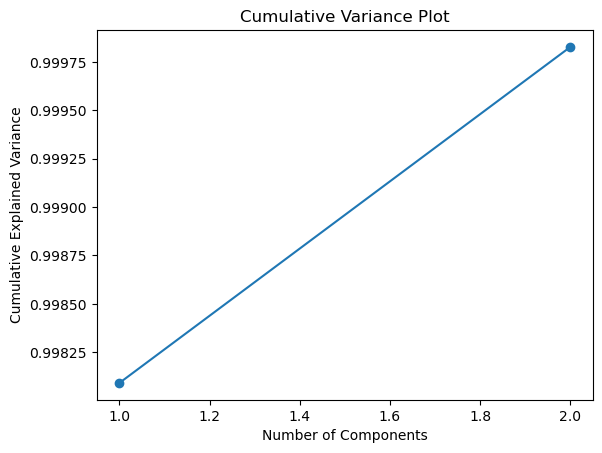

In [27]:
cum_var=np.cumsum(explained_variance)

plt.plot(range(1,len(cum_var)+1),cum_var,marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Plot")
plt.show()

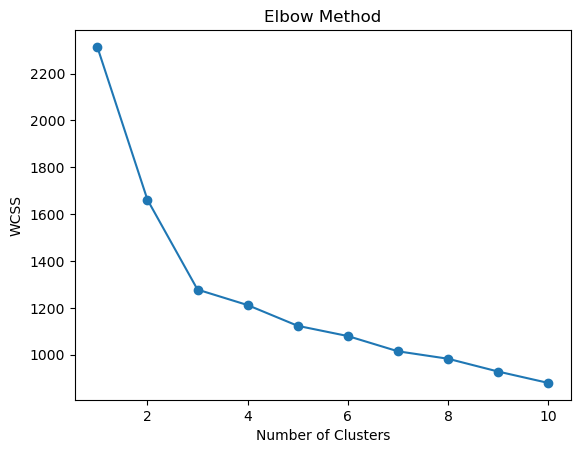

In [34]:
wcss=[]

for i in range(1,11):
    km=KMeans(n_clusters=i,random_state=42)
    km.fit(scaled_x)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

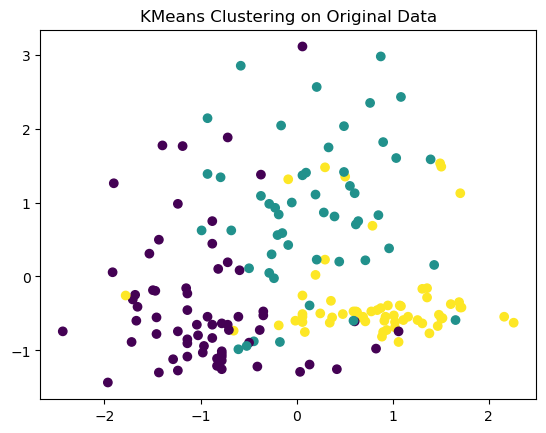

In [28]:
plt.scatter(scaled_x[:,0],scaled_x[:,1],c=model.labels_)
plt.title("KMeans Clustering on Original Data")
plt.show()

In [30]:
model_pca = KMeans(n_clusters=3,random_state=42)

pca_labels = model_pca.fit_predict(x_pca)

sil_score_pca = silhouette_score(x_pca, pca_labels)

db_score_pca = davies_bouldin_score(x_pca, pca_labels)

print("PCA Silhouette Score:",sil_score_pca)
print("PCA Davies Bouldin Score:",db_score_pca)

PCA Silhouette Score: 0.5602652844394511
PCA Davies Bouldin Score: 0.5487317536911426


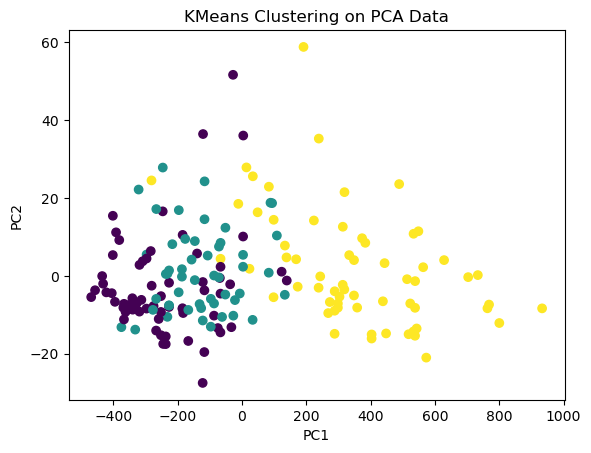

In [32]:
plt.scatter(x_pca[:,0],x_pca[:,1],c=model.labels_)
plt.title("KMeans Clustering on PCA Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Comparison Between Original Data and PCA Data

- Clustering was performed on both the original standardized dataset and the PCA-transformed dataset.
- PCA reduced the dimensionality of the dataset while preserving most of the important information.
- The PCA-transformed data provided better visualization of clusters in 2D space.
- Clustering on PCA data reduced computational complexity.
- Some information loss may occur after dimensionality reduction.
- The silhouette score and Davies-Bouldin index were used to compare clustering quality.

## Analysis of PCA Impact on Clustering

- PCA improves clustering performance by removing redundant and correlated features.
- Dimensionality reduction simplifies the dataset and improves visualization.
- PCA can help reduce noise in the data.
- However, excessive dimensionality reduction may lead to loss of important information.
- The trade-off between dimensionality reduction and information retention must be carefully balanced.

## Conclusion

- Principal Component Analysis (PCA) was successfully applied for dimensionality reduction.
- KMeans clustering was performed on both original and PCA-transformed datasets.
- PCA improved visualization and reduced computational complexity.
- Clustering evaluation metrics helped compare clustering quality.
- PCA is highly useful when working with high-dimensional datasets.
- Combining PCA with clustering techniques can improve data analysis and pattern discovery.

## Practical Implications

- PCA is useful in machine learning for reducing dataset size and improving efficiency.
- Clustering techniques help identify hidden patterns and groups in data.
- PCA and clustering are widely used in image processing, recommendation systems, healthcare, and finance.
- These techniques improve data understanding and model performance.

## Recommendations

- Use PCA when datasets contain many correlated features.
- Use clustering directly on original data when interpretability of features is important.
- PCA is recommended for visualization and faster computation.
- The number of principal components should be selected carefully to preserve important information.

## Interview Questions

### 1. What is PCA?
PCA is a dimensionality reduction technique used to reduce the number of features while preserving maximum variance.

### 2. Why is standardization important before PCA?
Because PCA is sensitive to feature scaling.

### 3. What is explained variance?
It represents the amount of information captured by each principal component.

### 4. What is KMeans clustering?
KMeans is an unsupervised learning algorithm used to group similar data points.

### 5. Why use silhouette score?
To measure clustering quality.

### 6. What is dimensionality reduction?
Reducing the number of input features while retaining important information.

### 7. What are principal components?
New transformed features generated by PCA.

### 8. What are the advantages of PCA?
- Reduces dimensions
- Removes multicollinearity
- Improves visualization
- Faster computation

### 9. What are limitations of PCA?
- Information loss
- Reduced interpretability

### 10. Difference between PCA and feature selection?
PCA creates new features, while feature selection chooses existing features.